**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
  - [Figure](#toc1_3_)    
    - [Preparation](#toc1_3_1_)    
    - [Figure](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore](#toc0_)

In [ ]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_3_single_f_PFA"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [7]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
total_photons_A = []
folder_path = reading_from + r"\bl_rate"
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_A.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            fingerprints_all_A[i] += pd.read_parquet(file).sum(axis=1)
            total_photons_A[i] += pd.read_parquet(file).sum(axis=0).values.tolist()
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [8]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
ON_periods_B_frames = []
folder_path = reading_from + r"\off_prob"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    ON_periods_B_frames.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                ON_periods_B_frames[i] += blinks.on_periods.tolist()
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [9]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
OFF_periods_C_frames = []
folder_path = reading_from + r"\off_time"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_C_frames.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_C_frames[i] += blinks.off_periods.tolist()
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint

## <a id='toc1_3_'></a>[Figure](#toc0_)

### <a id='toc1_3_1_'></a>[Preparation](#toc0_)

In [10]:
total_photons_A = [np.array(total_photons) for total_photons in total_photons_A]
minimum = np.min([np.min(a) for a in total_photons_A])
if minimum == 0:
    minimum = 1
maximum = np.max([np.max(a) for a in total_photons_A])
log_bins_A = np.logspace(np.log10(minimum), np.log10(maximum), 50)

# ON periods in seconds
ON_periods_B = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_B_frames]

# OFF periods in seconds
OFF_periods_C = [np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_C_frames]
minimum = np.min([np.min(a) for a in OFF_periods_C])
maximum = np.max([np.max(a) for a in OFF_periods_C])
log_bins_C = np.logspace(np.log10(minimum), np.log10(maximum), 50)

weights_B = [np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_B]
weights_C = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_C
]
weights_A = [
    np.ones_like(total_photons) / total_photons.size
    for total_photons in total_photons_A
]

### <a id='toc1_3_2_'></a>[Figure](#toc0_)

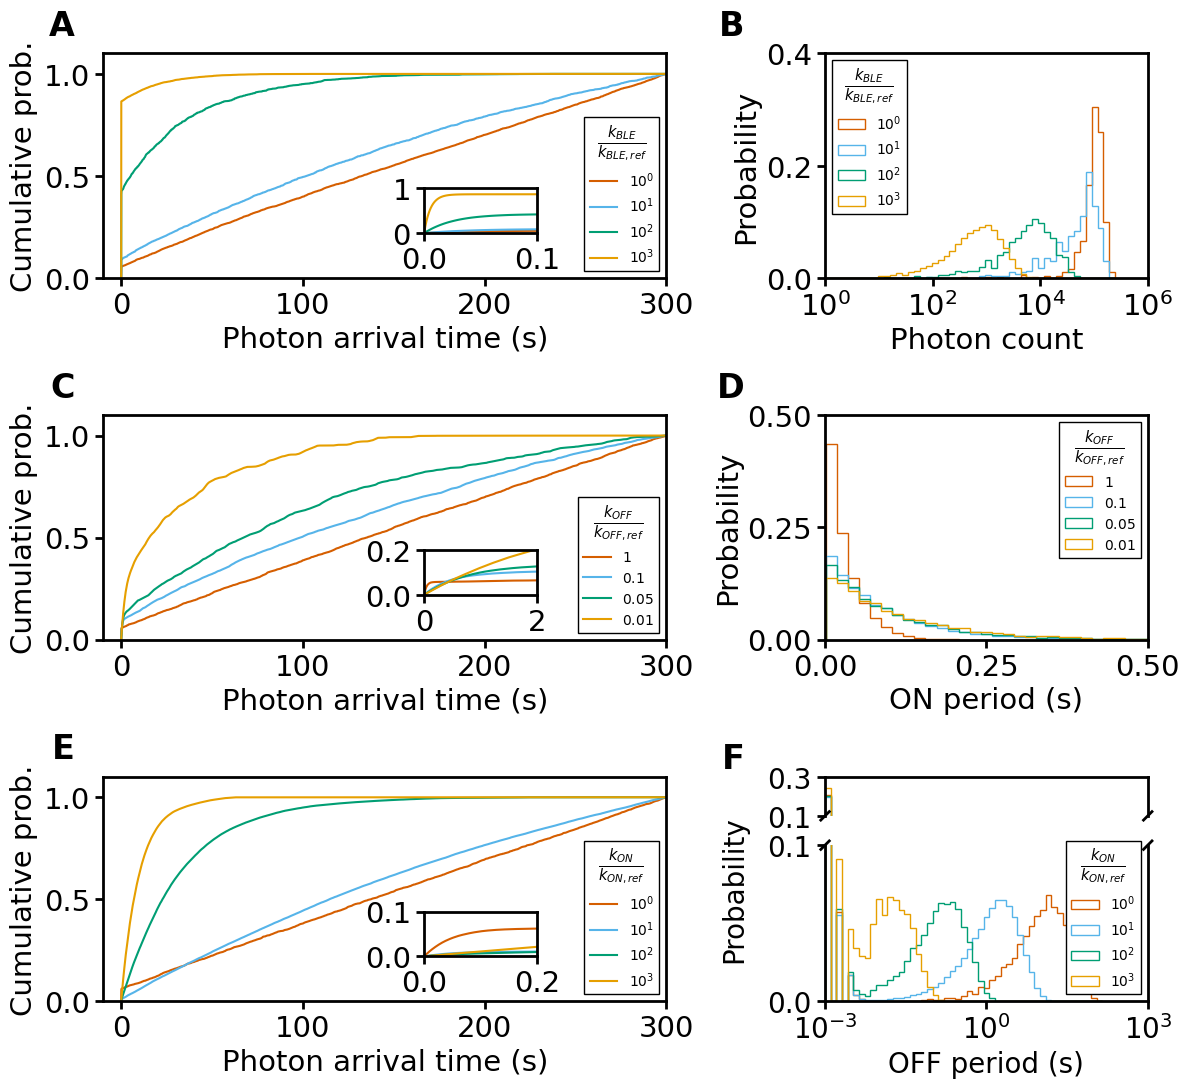

In [12]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(ax, labels, data, legendtitle, xlim2, ylim2, colors=colors):
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, label, color in zip(
        data,
        labels,
        colors,
    ):
        fi.universal_figure(
            data=[fingerprint.index, fingerprint],
            label=label,
            color=color,
            linestyle="-",
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=15,
        ),
        **description,
    )

    inset = ax.inset_axes([0.57, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index, fingerprint],
            axes=inset,
            label=label,
            color=color,
            linestyle="-",
        )
    inset.set_ylabel("")
    inset.set_xlabel("")


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 5)
fig = plt.figure(figsize=(12, 11))
ax1 = fig.add_subplot(gs[0, 0:3])
labels1 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle1 = r"$\frac{k_{BLE}}{k_{BLE,ref}}$"
plot_figure3(ax1, labels1, fingerprints_all_A, legendtitle1, 0.1, 1)
ax2 = fig.add_subplot(gs[0, 3:])
fi.universal_figure(
    type_="hist",
    data=list(reversed(total_photons_A)),
    axes=ax2,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_A)),
    xscale="log",
    bins=log_bins_A,
    ylim=[0, 0.4],
    xlim=[1e0, 1e6],
    ylabel="Probability",
    xlabel="Photon count",
    legend=True,
    legendargs=dict(
        title=legendtitle1,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=15,
    ),
)
ax3 = fig.add_subplot(gs[1, 0:3])
labels3 = [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"]
legendtitle3 = r"$\frac{k_{OFF}}{k_{OFF,ref}}$"
plot_figure3(
    ax3,
    labels3,
    fingerprints_all_B,
    legendtitle3,
    2,
    0.2,
)
ax4 = fig.add_subplot(gs[1, 3:])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_B)),
    axes=ax4,
    density=False,
    label=list(reversed(labels3)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_B)),
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    bins=60,
    legend=True,
    legendargs=dict(
        title=legendtitle3,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=15,
    ),
    ylim=[0, 0.5],
    xlim=[0, 0.5],
    xticks=[0, 0.25, 0.5],
    yticks=[0, 0.25, 0.5],
)
ax5 = fig.add_subplot(gs[2, 0:3])
labels5 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle5 = r"$\frac{k_{ON}}{k_{ON,ref}}$"
plot_figure3(
    ax5,
    labels5,
    fingerprints_all_C,
    legendtitle5,
    0.2,
    0.1,
)

bax6 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 3:],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax6.hist(
    list(reversed(OFF_periods_C)),
    density=False,
    histtype="step",
    label=list(reversed(labels5)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_C,
    weights=list(reversed(weights_C)),
)
bax6.set_xscale("log")
bax6.set_ylabel("Probability", fontsize=20, labelpad=55)
bax6.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax6.legend(
    title=legendtitle5,
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=15,
    loc="lower right",
    # bbox_to_anchor=(0.2, 0, 1, 1),
)
bax6.tick_params(labelsize=20, width=2, length=6)
bax6.set_xlim([1e-3, 1e3])
bax6.set_xticks([1e-3, 1e0, 1e3])
bax6.axs[0].set_yticks([0.1, 0.3])
bax6.axs[1].set_yticks([0, 0.1])

axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ["A", "B", "C", "D", "E", "F"])):
    offset = -0.05
    if i % 2 != 0:
        offset = -0.25
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
for handle in bax6.diag_handles:
    handle.remove()
bax6.draw_diags()
fig.savefig(
    reading_from + r"\single_f_PFA_without_fits.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)